# Tema 3. Modelado avanzado con algoritmos de ensamble y optimización supervisada

## 3.1 Modelos de ensamble para clasificación y regresión avanzada

### Paso 1: Preparar el dataset

In [1]:
import pandas as pd

df = pd.read_csv("Telco-Customer-Churn.csv")

# Limpieza simple
df = df[df["TotalCharges"] != " "]
df["TotalCharges"] = df["TotalCharges"].astype(float)

y = df["Churn"].map({"Yes": 1, "No": 0})
X = df.drop(columns=["customerID", "Churn"])

# One-hot encoding
X = pd.get_dummies(X, drop_first=True)


### Paso 2: División train/test


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


### Paso 3: Árbol de decisión (modelo de referencia)

In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
pred_tree = tree.predict(X_test)

print("Árbol F1-score:", f1_score(y_test, pred_tree))


Árbol F1-score: 0.46630727762803237


### Paso 4: Bagging simple


In [4]:
from sklearn.ensemble import BaggingClassifier

bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)

bag.fit(X_train, y_train)
pred_bag = bag.predict(X_test)

print("Bagging F1-score:", f1_score(y_test, pred_bag))


Bagging F1-score: 0.533724340175953


### Paso 5: Boosting simple


In [5]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42, n_estimators=50)
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)

print("Boosting F1-score:", f1_score(y_test, pred_gb))


Boosting F1-score: 0.5773809523809523


### Random Forest: principios, ventajas y limitaciones

#### Paso 1. Entrenamiento del modelo

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score

rf = RandomForestClassifier(
    n_estimators=300,      # Número de árboles (más árboles → menor varianza)
    max_depth=None,       # Profundidad libre (los árboles votan entre sí)
    max_features='sqrt',  # Selección aleatoria de variables por nodo
    random_state=42,
    n_jobs=-1             # Usa todos los núcleos disponibles
)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)


#### Paso 2. Evaluar el desempeño

In [7]:
print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf))
print("Random Forest F1:", f1_score(y_test, pred_rf))


Random Forest Accuracy: 0.7889125799573561
Random Forest F1: 0.5612998522895125


### Entrenamiento del modelo XGBoost

In [9]:
import xgboost as xgb
from sklearn.metrics import f1_score, accuracy_score

xgb_model = xgb.XGBClassifier(
    n_estimators=300,         # número de árboles
    learning_rate=0.05,      # shrinkage
    max_depth=5,             # árboles moderadamente profundos
    subsample=0.8,           # submuestreo de filas
    colsample_bytree=0.8,    # submuestreo de características
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, pred_xgb))
print("XGBoost F1:", f1_score(y_test, pred_xgb))


XGBoost Accuracy: 0.7818052594171997
XGBoost F1: 0.5633001422475107


### LighGBM


### Paso 1. Instalación

### Paso 2. Entrenamiento básico


In [10]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, f1_score

lgb_model = lgb.LGBMClassifier(
    n_estimators=300,       # número de árboles
    learning_rate=0.05,    # similar a XGBoost
    max_depth=-1,          # -1 = sin límite explícito, se controla con num_leaves
    num_leaves=31,         # controla la complejidad del árbol
    subsample=0.8,         # submuestreo de filas
    colsample_bytree=0.8,  # submuestreo de columnas
    random_state=42,
    n_jobs=-1
)

lgb_model.fit(X_train, y_train)
pred_lgb = lgb_model.predict(X_test)

print("LightGBM Accuracy:", accuracy_score(y_test, pred_lgb))
print("LightGBM F1:", f1_score(y_test, pred_lgb))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001047 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 637
[LightGBM] [Info] Number of data points in the train set: 5625, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265778 -> initscore=-1.016151
[LightGBM] [Info] Start training from score -1.016151
LightGBM Accuracy: 0.7825159914712153
LightGBM F1: 0.5616045845272206


## Tema 3.2 Ajuste de modelos con validación cruzada y búsqueda eficiente de parámetros

### Ajuste de hiperparámetros para XGBoost

#### Paso 1. Definir el espacio de búsqueda:

In [11]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import xgboost as xgb

param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6, 8],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 1, 3, 5]
}


#### Paso 2. Definir la validación cruzada estratificada

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


#### Paso 3. Configurar RandomizedSearchCV

In [14]:
xgb_clf = xgb.XGBClassifier(
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_dist,
    n_iter=30,
    scoring="f1",
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)


Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.6, 0.8, ...], 'gamma': [0, 1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], ...}"
,n_iter,30
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


#### Paso 4. Evaluación final

In [15]:
best_xgb = random_search.best_estimator_
pred_best = best_xgb.predict(X_test)

print("Mejor Modelo XGBoost - Accuracy:", accuracy_score(y_test, pred_best))
print("Mejor Modelo XGBoost - F1:", f1_score(y_test, pred_best))
print("Mejores hiperparámetros:", random_search.best_params_)


Mejor Modelo XGBoost - Accuracy: 0.8002842928216063
Mejor Modelo XGBoost - F1: 0.5956834532374101
Mejores hiperparámetros: {'subsample': 0.6, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.1, 'gamma': 5, 'colsample_bytree': 1.0}


## Tema 3.3 Métricas de evaluación y diagnóstico de errores en modelos supervisados

#### Paso 1. Importaciones mediciones y métricas


In [16]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve,
)
import seaborn as sns
import matplotlib.pyplot as plt

# Predicciones
pred = best_xgb.predict(X_test)
pred_prob = best_xgb.predict_proba(X_test)[:, 1]

# Métricas
print("Accuracy:", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall:", recall_score(y_test, pred))
print("F1-score:", f1_score(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, pred_prob))


Accuracy: 0.8002842928216063
Precision: 0.6448598130841121
Recall: 0.553475935828877
F1-score: 0.5956834532374101
ROC-AUC: 0.8398737388117264


#### Matriz de Confusión

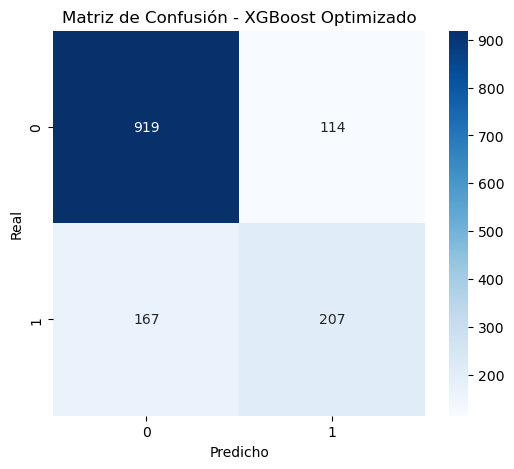

In [17]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - XGBoost Optimizado")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()


#### Curva ROC


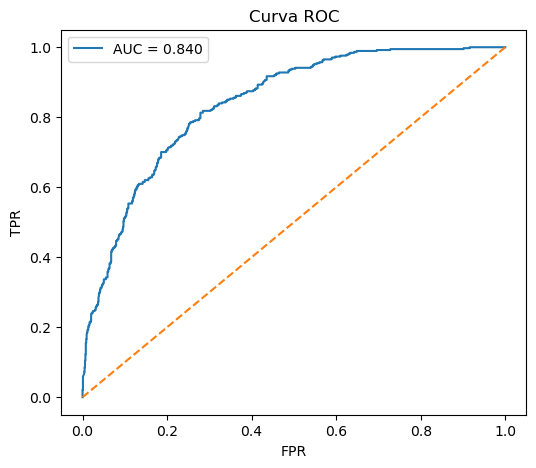

In [18]:
fpr, tpr, _ = roc_curve(y_test, pred_prob)
auc_value = roc_auc_score(y_test, pred_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_value:.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.title("Curva ROC")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()


#### Curva Precision-Recall


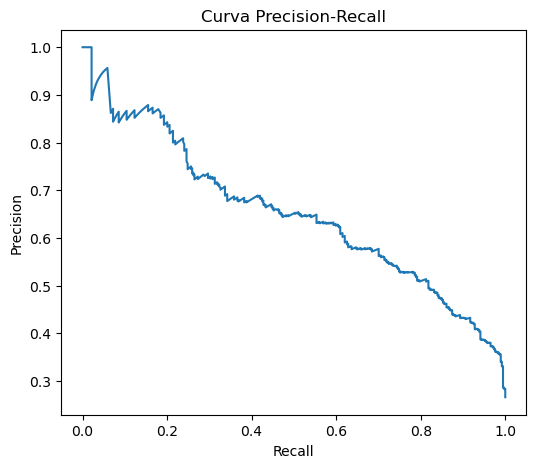

In [19]:
prec, rec, _ = precision_recall_curve(y_test, pred_prob)

plt.figure(figsize=(6, 5))
plt.plot(rec, prec)
plt.title("Curva Precision-Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()
